# TensorFlow Specialization - Course 2, Week 1
## Practice Notebook: Cats vs Dogs Image Classification

This notebook provides hands-on practice with the concepts covered in Week 1. You'll build a complete CNN pipeline from scratch, exploring each component in detail.

**Topics Covered:**
1. Data Exploration and Visualization
2. Directory Structure Setup
3. Building CNN Architecture
4. Data Preprocessing Pipeline
5. Model Training
6. Prediction and Testing
7. Visualization of Feature Maps
8. Performance Analysis

## Setup: Import Required Libraries

First, we'll import all necessary libraries for working with images, building neural networks, and visualizing results.

In [3]:
%pip install tensorflow

  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.4/620.4 MB 19.2 MB/s  0:00:28m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 22.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.8 MB/s  0:00:00 eta 0:00:01
Using cached idna-3.10-py3-none-any.whl (70 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 31.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.5 MB/s  0:00:00m0:00:01
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 34.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 22.3 MB/s  0:00:01m0:00:0100:01
   ━━━

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow version: {tf.__version__}")

2025-10-06 15:02:15.303408: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-06 15:02:15.365750: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 15:02:16.705041: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0


---
## Part 1: Dataset Exploration

### Understanding the Directory Structure

The cats and dogs dataset is organized in subdirectories. Proper organization allows TensorFlow to automatically label images based on their folder names.

**Expected Structure:**
```
cats_and_dogs_filtered/
├── train/
│   ├── cats/
│   └── dogs/
└── validation/
    ├── cats/
    └── dogs/
```

In [5]:
import urllib.request
import zipfile
import os

# Download the filtered dataset (smaller, already cleaned)
url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
filename = "cats_and_dogs_filtered.zip"

urllib.request.urlretrieve(url, filename)

# Unzip
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [6]:
# Define base directory - adjust this path to where your data is stored
BASE_DIR = './data/cats_and_dogs_filtered'

# Define subdirectories
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

# Training directories
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Validation directories
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

# Display directory structure
print("Directory Structure:")
print(f"Base: {BASE_DIR}")
print(f"├── Train: {train_dir}")
print(f"│   ├── Cats: {train_cats_dir}")
print(f"│   └── Dogs: {train_dogs_dir}")
print(f"└── Validation: {validation_dir}")
print(f"    ├── Cats: {validation_cats_dir}")
print(f"    └── Dogs: {validation_dogs_dir}")

Directory Structure:
Base: ./data/cats_and_dogs_filtered
├── Train: ./data/cats_and_dogs_filtered/train
│   ├── Cats: ./data/cats_and_dogs_filtered/train/cats
│   └── Dogs: ./data/cats_and_dogs_filtered/train/dogs
└── Validation: ./data/cats_and_dogs_filtered/validation
    ├── Cats: ./data/cats_and_dogs_filtered/validation/cats
    └── Dogs: ./data/cats_and_dogs_filtered/validation/dogs


### Count Images in Each Category

Let's verify how many images we have for training and validation. A balanced dataset (equal cats and dogs) helps the model learn both classes equally well.

In [7]:
# Count training images
num_train_cats = len(os.listdir(train_cats_dir))
num_train_dogs = len(os.listdir(train_dogs_dir))
total_train = num_train_cats + num_train_dogs

# Count validation images
num_val_cats = len(os.listdir(validation_cats_dir))
num_val_dogs = len(os.listdir(validation_dogs_dir))
total_val = num_val_cats + num_val_dogs

print("Training Images:")
print(f"  Cats: {num_train_cats}")
print(f"  Dogs: {num_train_dogs}")
print(f"  Total: {total_train}")
print("\nValidation Images:")
print(f"  Cats: {num_val_cats}")
print(f"  Dogs: {num_val_dogs}")
print(f"  Total: {total_val}")
print(f"\nGrand Total: {total_train + total_val} images")

Training Images:
  Cats: 1000
  Dogs: 1000
  Total: 2000

Validation Images:
  Cats: 500
  Dogs: 500
  Total: 1000

Grand Total: 3000 images


### Visualize Sample Images

Before training, it's crucial to look at the actual images. This helps you understand:
- Image quality and variety
- Different poses and backgrounds
- Potential data issues (corrupt images, incorrect labels)

Run this cell multiple times to see different random samples!

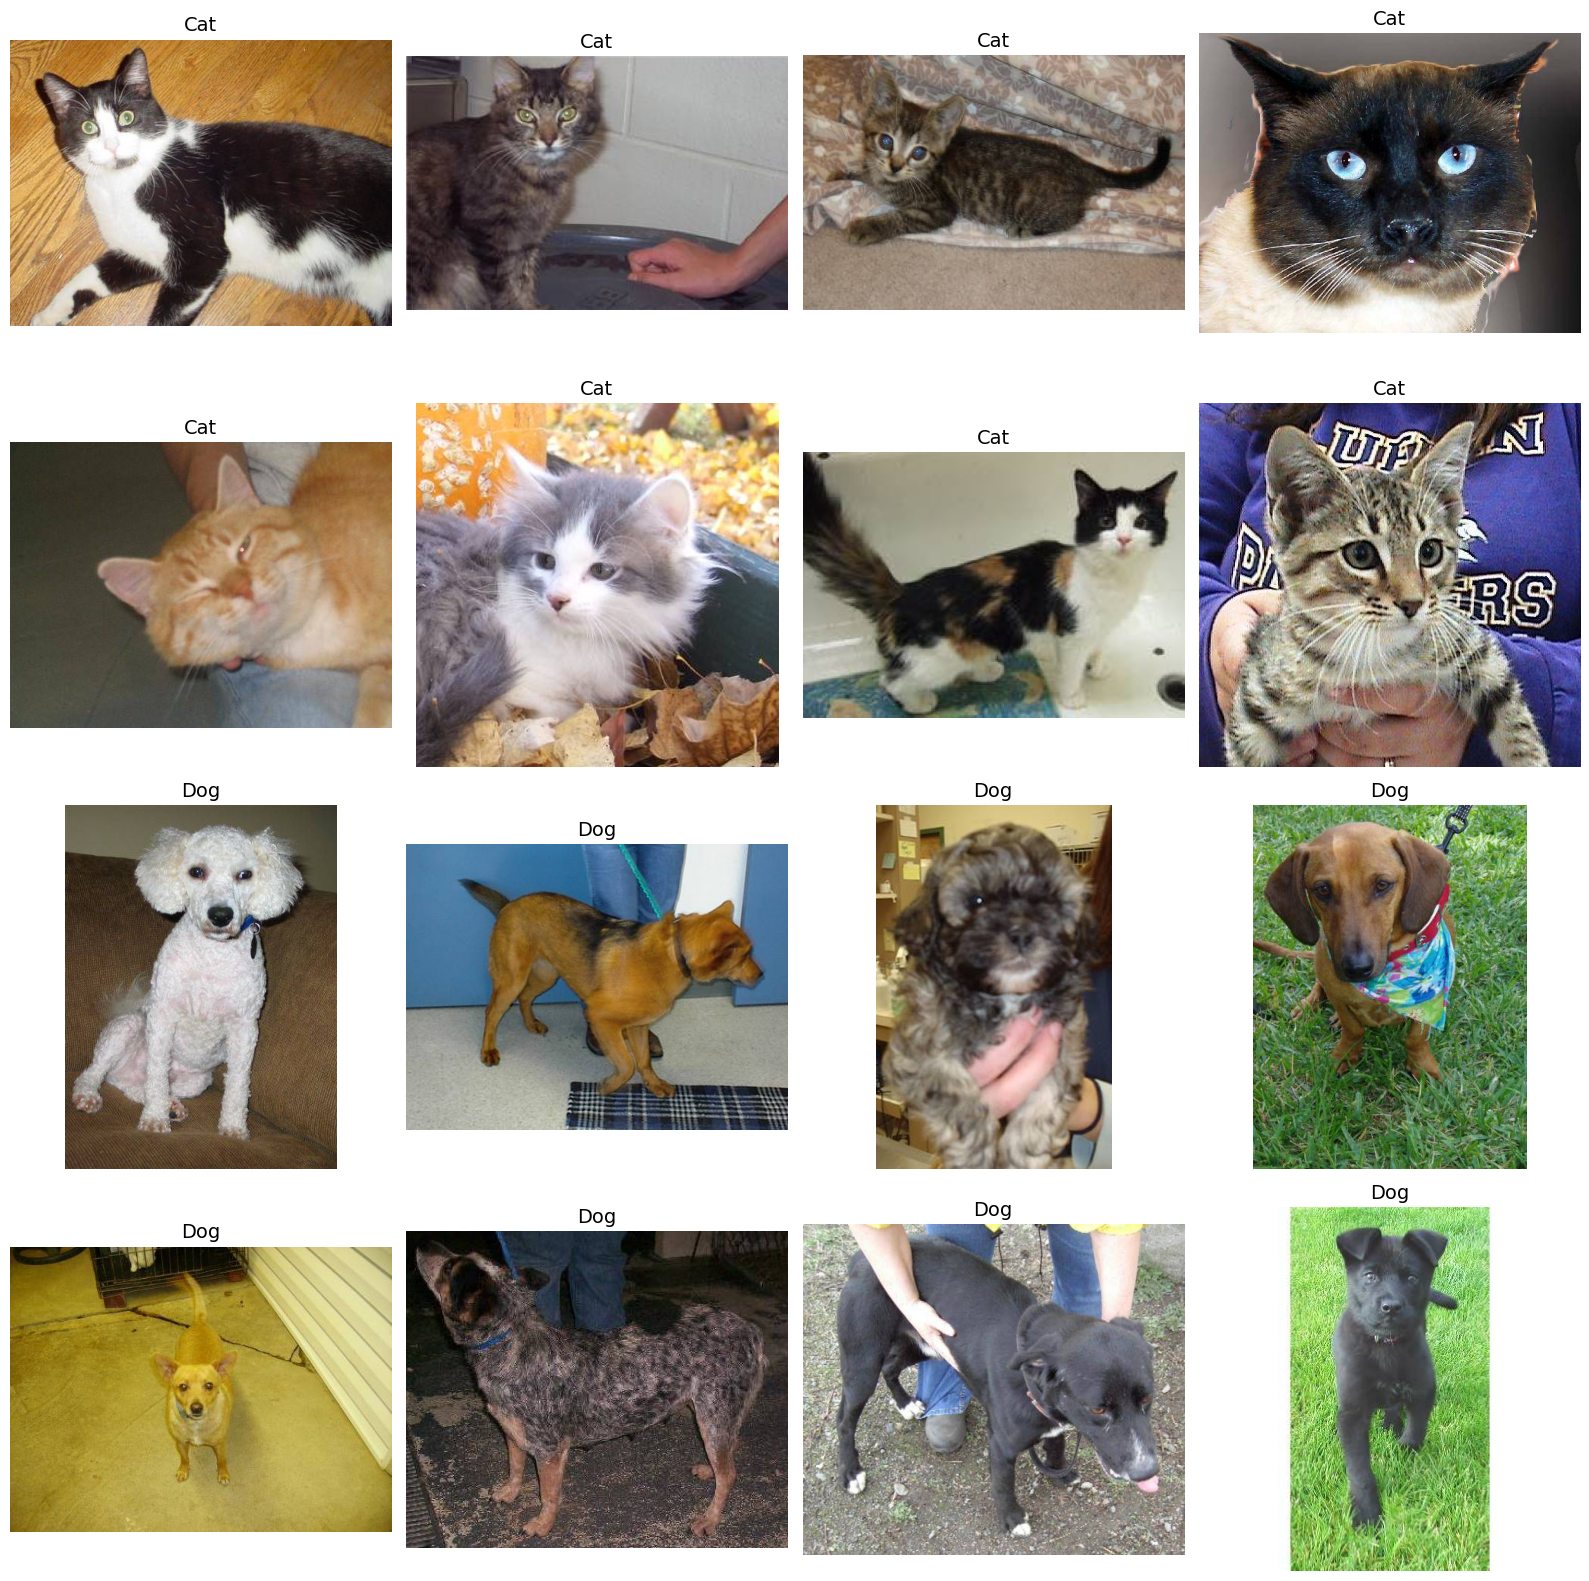

In [8]:
# Get all filenames
train_cat_fnames = os.listdir(train_cats_dir)
train_dog_fnames = os.listdir(train_dogs_dir)

# Setup figure
nrows, ncols = 4, 4
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

# Randomly select 8 cats and 8 dogs
cat_pics = [os.path.join(train_cats_dir, fname) 
            for fname in random.sample(train_cat_fnames, k=8)]
dog_pics = [os.path.join(train_dogs_dir, fname) 
            for fname in random.sample(train_dog_fnames, k=8)]

# Display images
for i, img_path in enumerate(cat_pics + dog_pics):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')
    
    img = mpimg.imread(img_path)
    plt.imshow(img)
    
    # Add label
    label = "Cat" if i < 8 else "Dog"
    plt.title(label, fontsize=14)

plt.tight_layout()
plt.show()

---
## Part 2: Data Loading with TensorFlow

### Using `image_dataset_from_directory`

TensorFlow provides a convenient function that:
1. Loads images from directories
2. Automatically labels them based on folder names
3. Resizes images to a uniform size
4. Creates batches for training

**Key Parameters:**
- `image_size`: Target size for all images (we'll use 150x150)
- `batch_size`: Number of images per batch (affects memory and training speed)
- `label_mode`: 'binary' for two classes (cat vs dog)

In [9]:
# Define parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 20

# Create training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Create validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


2025-10-06 15:06:26.606214: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Optimize Dataset Performance

These optimizations significantly speed up training:
- **cache()**: Keeps dataset in memory after first epoch
- **shuffle()**: Randomizes order to prevent learning patterns in data ordering
- **prefetch()**: Prepares next batch while GPU trains on current batch

In [10]:
# Optimization parameters
SHUFFLE_BUFFER_SIZE = 1000
AUTOTUNE = tf.data.AUTOTUNE

# Apply optimizations
train_dataset = train_dataset.cache().shuffle(SHUFFLE_BUFFER_SIZE).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset optimizations applied successfully!")
print(f"Training batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(validation_dataset).numpy()}")

Dataset optimizations applied successfully!
Training batches: 100
Validation batches: 50


### Inspect a Batch

Let's examine what a single batch looks like. This helps verify:
- Correct image dimensions
- Pixel value range (should be 0-255 before rescaling)
- Label format

In [11]:
# Get one batch
for images, labels in train_dataset.take(1):
    sample_images = images
    sample_labels = labels

print("Batch Information:")
print(f"  Images shape: {sample_images.shape}")
print(f"  Labels shape: {sample_labels.shape}")
print(f"  Image data type: {sample_images.dtype}")
print(f"  Pixel value range: [{np.min(sample_images):.1f}, {np.max(sample_images):.1f}]")
print(f"  Sample labels: {sample_labels.numpy()[:5]}")

Batch Information:
  Images shape: (20, 150, 150, 3)
  Labels shape: (20, 1)
  Image data type: <dtype: 'float32'>
  Pixel value range: [0.0, 255.0]
  Sample labels: [[0.]
 [1.]
 [0.]
 [1.]
 [1.]]


2025-10-06 15:06:49.535387: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## Part 3: Building the CNN Model

### Model Architecture Design

We'll build a CNN with:
1. **Input Layer**: Specifies image dimensions (150x150x3)
2. **Rescaling Layer**: Normalizes pixel values from [0,255] to [0,1]
3. **Three Conv-Pool Blocks**: Extract features at different levels
4. **Dense Layers**: Combine features for classification
5. **Output Layer**: Single sigmoid neuron for binary classification

**Architecture Pattern:**
- Filters increase: 16 → 32 → 64 (more complex features in deeper layers)
- Spatial dimensions decrease: 150x150 → 17x17 (through pooling)
- Feature depth increases: 3 → 64 (more feature maps)

In [12]:
# Build the model
model = tf.keras.models.Sequential([
    # Input layer - specify image shape
    tf.keras.Input(shape=(150, 150, 3)),
    
    # Rescaling layer - normalize pixel values
    tf.keras.layers.Rescaling(1./255),
    
    # First convolution block
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', name='conv1'),
    tf.keras.layers.MaxPooling2D(2, 2, name='pool1'),
    
    # Second convolution block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv2'),
    tf.keras.layers.MaxPooling2D(2, 2, name='pool2'),
    
    # Third convolution block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),
    tf.keras.layers.MaxPooling2D(2, 2, name='pool3'),
    
    # Flatten to 1D
    tf.keras.layers.Flatten(),
    
    # Dense hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    
    # Output layer - binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print("Model created successfully!")

Model created successfully!


### View Model Architecture

The model summary shows:
- Layer names and types
- Output shape after each layer
- Number of parameters (weights) to train

Watch how dimensions change through the network!

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

Before training, we must compile the model by specifying:
- **Optimizer**: Algorithm to update weights (RMSprop or Adam work well)
- **Loss function**: binary_crossentropy for binary classification
- **Metrics**: What to monitor during training (accuracy)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled and ready for training!")

Model compiled and ready for training!


---
## Part 4: Training the Model

### Start Training

During training, the model:
1. Sees batches of training images
2. Makes predictions
3. Calculates error (loss)
4. Updates weights to reduce error
5. Validates on unseen data

**What to watch:**
- Training accuracy should increase
- Training loss should decrease
- Gap between training and validation metrics indicates overfitting

In [15]:
# Train the model
EPOCHS = 15

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - accuracy: 0.5170 - loss: 0.7401 - val_accuracy: 0.6080 - val_loss: 0.6733
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.6305 - loss: 0.6422 - val_accuracy: 0.6860 - val_loss: 0.5818
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.7015 - loss: 0.5824 - val_accuracy: 0.6780 - val_loss: 0.5998
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.7500 - loss: 0.5157 - val_accuracy: 0.6990 - val_loss: 0.5773
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.7820 - loss: 0.4604 - val_accuracy: 0.6930 - val_loss: 0.6059
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.8225 - loss: 0.3992 - val_accuracy: 0.7390 - val_loss: 0.5468
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.8615 - loss: 0.3307 - val_accuracy: 0.7420 - val_loss: 0.5914
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.9030 - loss: 0

---
## Part 5: Analyzing Training Results

### Plot Training History

Visualizing accuracy and loss curves helps identify:
- Whether the model is learning
- When overfitting starts
- Optimal number of epochs

**Healthy training**: Training and validation metrics improve together  
**Overfitting**: Training improves but validation plateaus or worsens

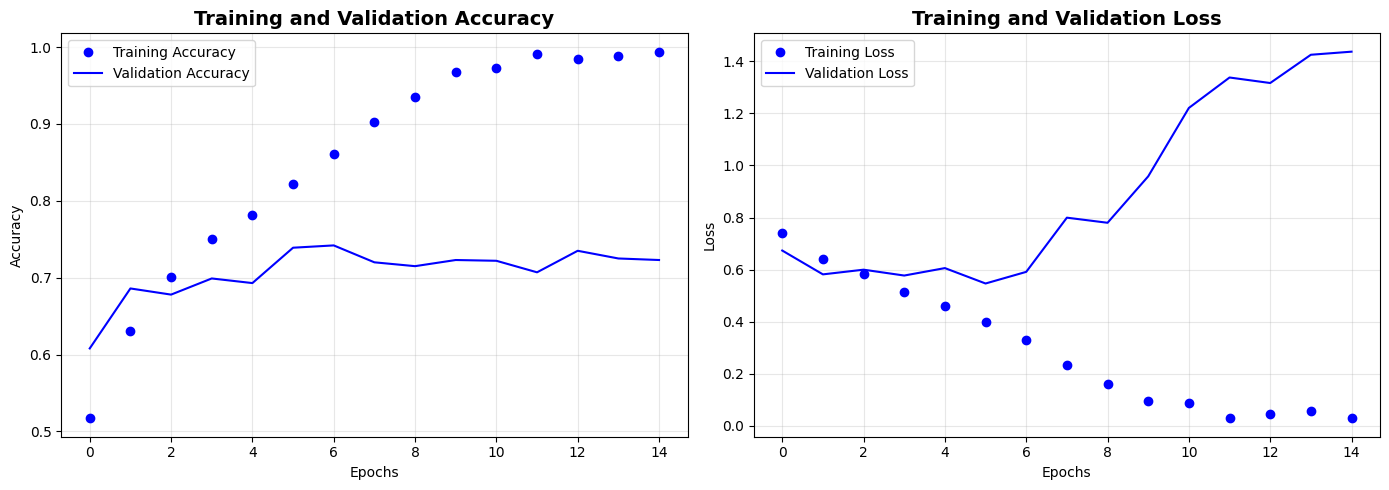


Final Training Accuracy: 0.9940
Final Validation Accuracy: 0.7230
Best Validation Accuracy: 0.7420 at epoch 7


In [16]:
# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs_range, acc, 'bo', label='Training Accuracy')
ax1.plot(epochs_range, val_acc, 'b', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs_range, loss, 'bo', label='Training Loss')
ax2.plot(epochs_range, val_loss, 'b', label='Validation Loss')
ax2.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Best Validation Accuracy: {max(val_acc):.4f} at epoch {val_acc.index(max(val_acc)) + 1}")

### Analyze Overfitting

Calculate the gap between training and validation accuracy to quantify overfitting.

In [17]:
# Calculate overfitting metrics
final_gap = acc[-1] - val_acc[-1]
max_gap = max([a - v for a, v in zip(acc, val_acc)])

print("Overfitting Analysis:")
print(f"  Final accuracy gap: {final_gap:.4f}")
print(f"  Maximum accuracy gap: {max_gap:.4f}")

if final_gap > 0.15:
    print("  ⚠️  Model is overfitting - consider data augmentation or regularization")
else:
    print("  ✓ Overfitting is under control")

Overfitting Analysis:
  Final accuracy gap: 0.2710
  Maximum accuracy gap: 0.2845
  ⚠️  Model is overfitting - consider data augmentation or regularization


---
## Part 6: Testing Predictions

### Predict on Sample Images

Let's test the model on actual images from the validation set. The model outputs a value between 0 and 1:
- Close to 0 → Cat
- Close to 1 → Dog
- Around 0.5 → Uncertain

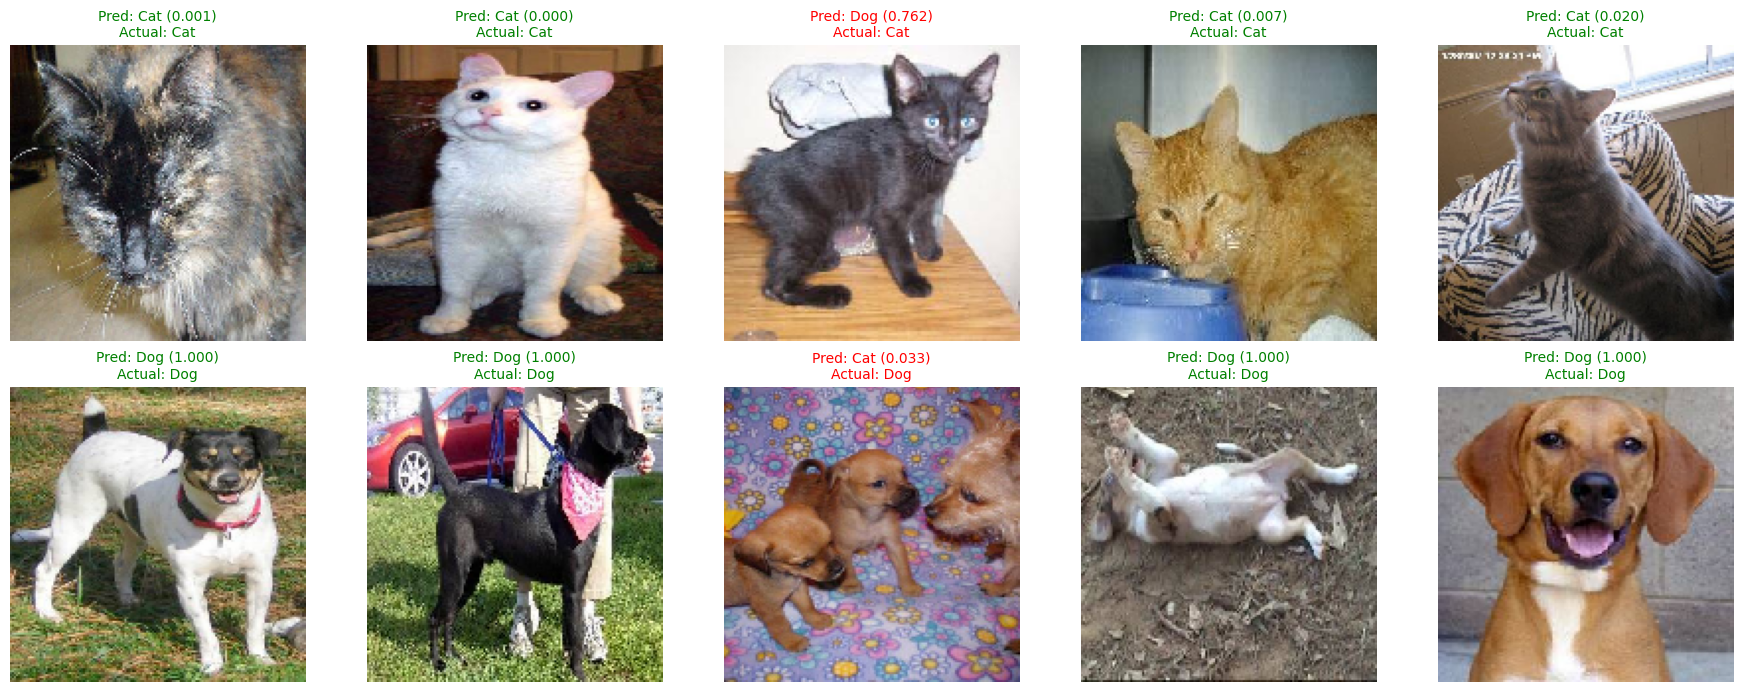

In [18]:
# Get validation filenames
val_cat_files = [os.path.join(validation_cats_dir, f) for f in os.listdir(validation_cats_dir)[:5]]
val_dog_files = [os.path.join(validation_dogs_dir, f) for f in os.listdir(validation_dogs_dir)[:5]]
test_files = val_cat_files + val_dog_files

# Setup plot
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

# Make predictions
for idx, img_path in enumerate(test_files):
    # Load and preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    
    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]
    
    # Determine class
    predicted_class = "Dog" if prediction > 0.5 else "Cat"
    actual_class = "Cat" if idx < 5 else "Dog"
    correct = predicted_class == actual_class
    
    # Display
    axes[idx].imshow(img)
    axes[idx].axis('off')
    color = 'green' if correct else 'red'
    axes[idx].set_title(
        f"Pred: {predicted_class} ({prediction:.3f})\nActual: {actual_class}",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

---
## Part 7: Visualizing Feature Maps

### Understanding What the CNN Learns

We can visualize the intermediate outputs (feature maps) from each convolutional layer to see what features the network detects:
- **Early layers**: Edges, colors, simple textures
- **Middle layers**: Patterns, shapes
- **Deep layers**: Complex features specific to cats/dogs

In [24]:
# Pass a sample image through the model first to initialize it
_ = model.predict(sample_images[:1], verbose=0)

# Now create the visualization model
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'pool' in layer.name]
visualization_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

# Load a random test image
test_img_path = random.choice(val_cat_files + val_dog_files)
img = tf.keras.utils.load_img(test_img_path, target_size=(150, 150))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Get feature maps
feature_maps = visualization_model.predict(img_array, verbose=0)

# Get layer names
layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'pool' in layer.name]

print(f"Visualizing feature maps for: {os.path.basename(test_img_path)}")
print(f"Number of layers to visualize: {len(layer_names)}")

Visualizing feature maps for: dog.2276.jpg
Number of layers to visualize: 6


### Display Feature Maps

Each row shows all filters from one layer. Watch how:
- Early layers preserve spatial detail
- Deep layers become more abstract
- Some filters activate strongly (bright), others barely at all (dark)

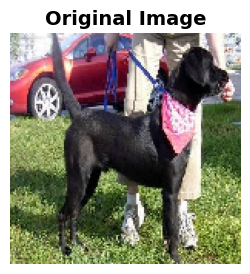

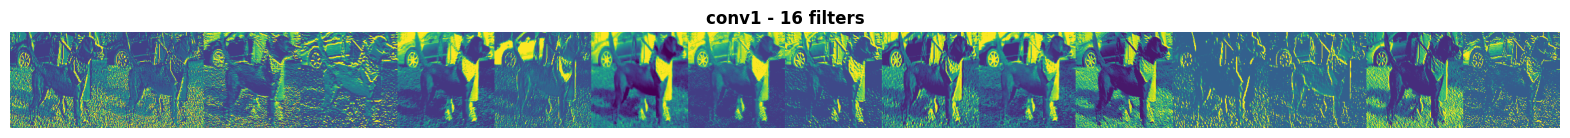

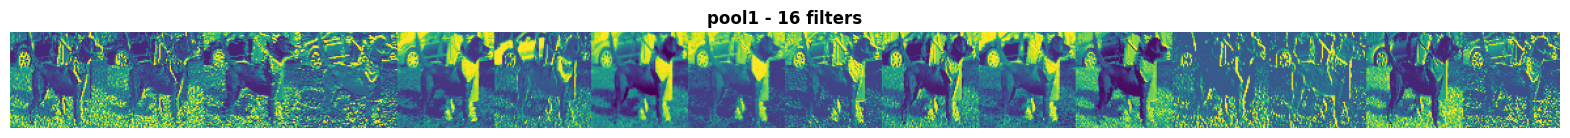

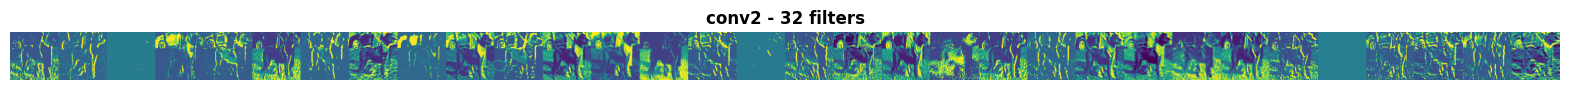

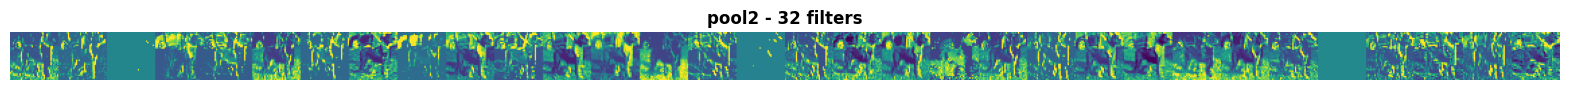

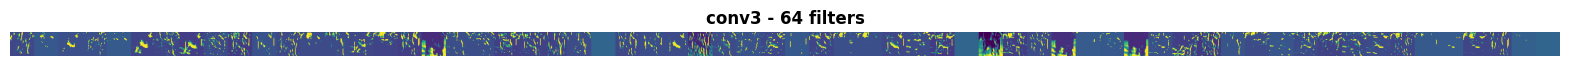

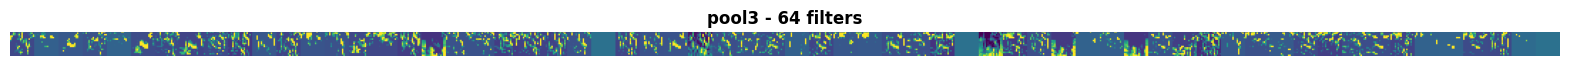

In [25]:
# Plot original image first
plt.figure(figsize=(12, 3))
plt.imshow(img)
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

# Plot feature maps for each layer
for layer_name, feature_map in zip(layer_names, feature_maps):
    n_features = feature_map.shape[-1]  # Number of filters
    size = feature_map.shape[1]  # Spatial dimensions
    
    # Create grid for all filters
    display_grid = np.zeros((size, size * n_features))
    
    # Fill the grid
    for i in range(n_features):
        x = feature_map[0, :, :, i]
        # Normalize for visualization
        x -= x.mean()
        x /= (x.std() + 1e-5)
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, i * size:(i + 1) * size] = x
    
    # Display
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(f'{layer_name} - {n_features} filters', fontsize=12, fontweight='bold')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

---
## Part 8: Model Evaluation

### Comprehensive Performance Metrics

Beyond accuracy, let's calculate additional metrics to better understand model performance.

In [21]:
# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(validation_dataset, verbose=0)

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("="*50)

# Performance assessment
if val_accuracy >= 0.80:
    print("✓ Excellent performance!")
elif val_accuracy >= 0.70:
    print("✓ Good performance, but room for improvement")
else:
    print("⚠️  Consider data augmentation or transfer learning")

FINAL MODEL PERFORMANCE
Validation Loss: 1.4367
Validation Accuracy: 0.7230 (72.30%)
✓ Good performance, but room for improvement


---
## Part 9: Save the Model

### Save for Later Use

Save the trained model so you can use it later without retraining.

In [22]:
# Save the model
model.save('cats_vs_dogs_model.keras')
print("Model saved successfully!")

# To load later:
# loaded_model = tf.keras.models.load_model('cats_vs_dogs_model.keras')

Model saved successfully!


---
## Summary and Key Takeaways

### What You've Learned

1. **Data Organization**: Proper directory structure enables automatic labeling
2. **Data Pipeline**: Using TensorFlow's utilities for efficient data loading
3. **CNN Architecture**: Building convolutional networks with progressive feature extraction
4. **Training Process**: Monitoring metrics and identifying overfitting
5. **Visualization**: Understanding what CNNs learn through feature maps
6. **Evaluation**: Assessing model performance on unseen data

### Current Limitations

- Model shows overfitting (training accuracy >> validation accuracy)
- Validation accuracy plateaus around 70-75%
- Limited training data (2,000 images)

### Next Steps (Week 2)

- **Data Augmentation**: Create variations of training images
- **Regularization**: Add dropout and other techniques
- **Better Performance**: Aim for 85%+ validation accuracy

---

## Practice Exercises

Try these modifications to deepen your understanding:

1. **Change batch size** to 32 or 64 and observe training speed
2. **Modify architecture** by adding/removing convolution layers
3. **Adjust learning rate** in the optimizer (try 0.0001 or 0.01)
4. **Add more filters** in Conv2D layers (e.g., 32, 64, 128)
5. **Experiment with optimizers** (try Adam instead of RMSprop)
6. **Test on your own images** by adding image upload functionality

Remember: The best way to learn is by experimenting!